In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [17]:
## credit-card-fraud-detection dataset from kaggle.
df = pd.read_csv("creditcard.csv")

X = df.drop(columns=["Class"]).values.astype(np.float64)  # Time, V1..V28, Amount
y = df["Class"].values.astype(np.float64)                 # 0/1

print("Shape X:", X.shape, " | Shape y:", y.shape)
print("Fraud count:", int(y.sum()), "  Fraud %:", 100*y.mean())

Shape X: (284807, 30)  | Shape y: (284807,)
Fraud count: 492   Fraud %: 0.1727485630620034


In [18]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

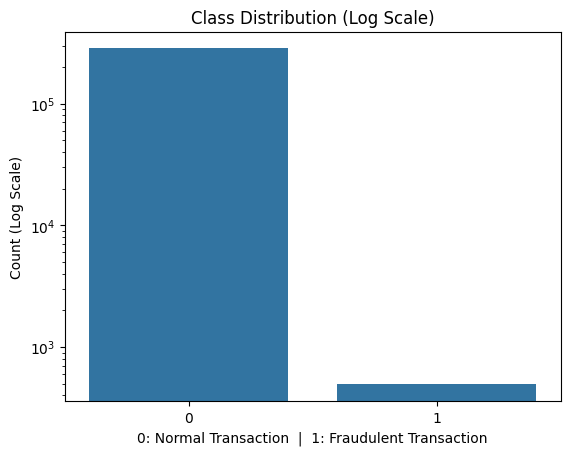

In [20]:
import seaborn as sns
sns.countplot(x='Class', data=df)
plt.yscale('log') 
plt.title("Class Distribution (Log Scale)")
plt.xlabel("0: Normal Transaction  |  1: Fraudulent Transaction")
plt.ylabel("Count (Log Scale)")

plt.show()

In [21]:
corr=df.corr()
corr.shape

(31, 31)

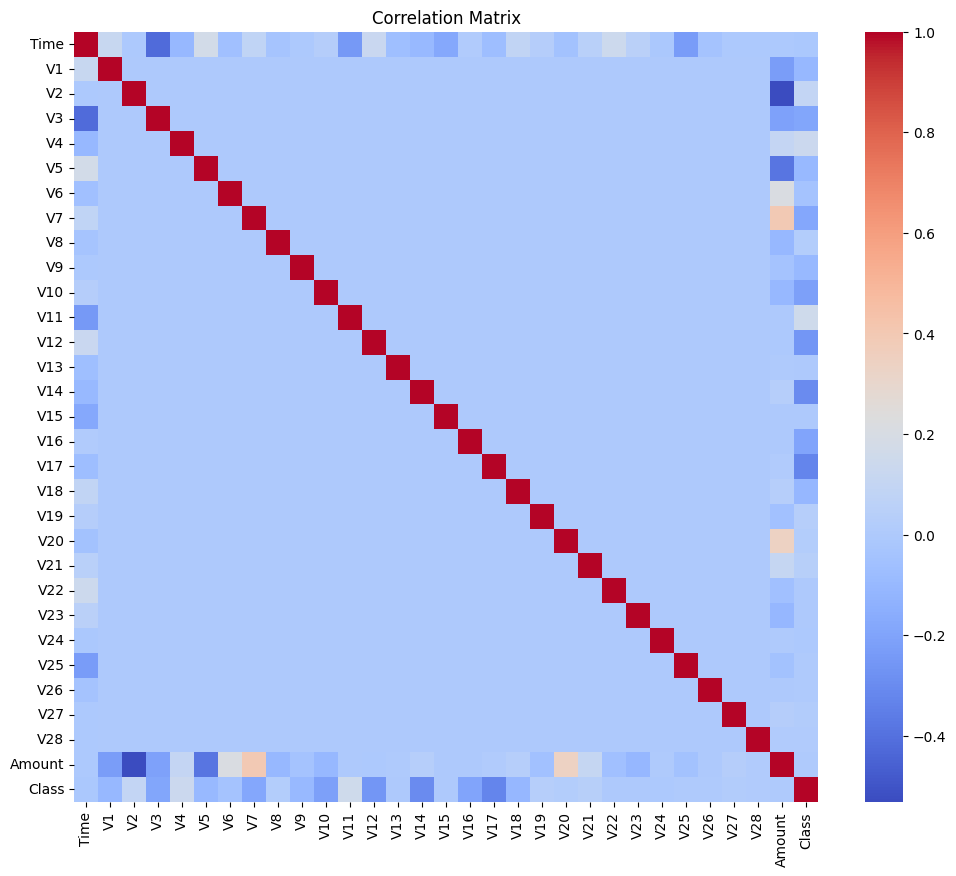

In [22]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot_kws={'size':20})
plt.title("Correlation Matrix")
plt.show()

In [23]:
fraud=df[df['Class'] == 1]
non_fraud=df[df['Class'] == 0]
fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


In [24]:
# 80% trainval, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# from trainval, take 20% as val => overall val=16% of full data
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42)

In [25]:
# ZSCORE NORMALIZATION
# standardizing the data
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
eps = 1e-15

X_train_s = (X_train - mu) / (sigma + eps)
X_val_s = (X_val - mu) / (sigma + eps)
X_test_s = (X_test - mu) / (sigma + eps)
print("Standardised shapes:")
print(X_train_s.shape)
print(X_val_s.shape)
print(X_test_s.shape)

Standardised shapes:
(182276, 30)
(45569, 30)
(56962, 30)


In [26]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logloss(y, p):
    p = np.clip(p, eps, 1 - eps) # Avoid log(0) by clipping probabilities
    losses = -(y*np.log(p) + (1-y)*np.log(1-p)) 
    
    return np.mean(losses)

def compute_class_weights(y):
    # Balanced weights: w1=N/(2N1), w0=N/(2N0)
    n = len(y)
    n1 = np.sum(y == 1)
    n0 = n - n1
    w1 = n / (2 * max(1.0, n1))
    w0 = n / (2 * max(1.0, n0))
    return float(w0), float(w1)